Introduction to Python Programming for the Physical sciences:
- Based on [Introduction to Computer Programming for the Physical Sciences](https://nexsci.caltech.edu/workshop/Python_Introduction_Timothy_Brandt.pdf ) by Timothy Brandt (UC Santa Barabara)


# **Chapter 1:**
Selected Terminology:
- Variable - text that stores a value
- Comment - text to "comment" upon the code without changing the computation
- function - set of instructions to take inputs (arguments) to produce an output.
- loop - a set of instructions that are executed repeatedly
- bug - mistake in code
- module - python package
- floating point - real number stored in scientific notation
- lamba - defining a function in one line in python

Notes:
- Arithmetic must use basic operaters (+, -, *, /, **)
- Arithmetic must be performed to the right of a variable, and will following standard order of operations.
- Proper scientific notation is best designated using "e", for example 3e8 as opposed to 3*10**8, because the latter is computed improperly.

---

**Chapter 2**:

Functions can either be taken from modules like numpy or defined directly, both are shown below.

Note: The indent in the definition of a function is what tells the computer that it is within the function, this is why the indent goes away once I try to print the square of .5.

In [55]:
import numpy as np

#returns the sine of .5
y = np.sin(0.5)
print(y)

#defines the square function
def sqr(x):
  return x**2

#takes the square of .5
print(sqr(.5))


0.479425538604203
0.25


When you are defining a variable within a function definition, that variable is only definied within that section of the code, so if I were to call something x within the function and try to call another variable of name x, a nameerror will be thrown. Or if it existed prior, nothing will change as seen below.

In [56]:
x=5
def sqr(x):
  return x**2
print(x)

5


Functions themselves can also be passed into another argument as seen below.

In [57]:
def func_sqr(f, x):
  return f(x)**2

sinsq_x = func_sqr(np.sin,x)

print(sinsq_x)

0.9195357645382262


Conditionals operate differently based on whatever the input is. For example, if we want to define a simple abs value function:   

In [58]:
x=-3e8
def abs(x):
  if x >=0:
    return x
  else:
    return x*-1

print(abs(x))


300000000.0


Another example is the sinc function, which is used often in Signal Transformations:

In [59]:
def sinc(x):
  if x==0:
    return 1
  else:
    return np.sin(x)/x

print(sinc(5))


-0.1917848549326277


One last example is electric potential V(r) from the center of a spherical center of charge q.

$$V(r) = \begin{cases} \frac{kQ}{r} & r > R \\ \frac{kQ}{R} & r \leq R \end{cases}$$


In [60]:
Q = 1
R = 1
r = 2
def potential_sphere(Q, R, r):
  k = 8.988e9
  if R > r:
    return k*Q/R
  else:
    return k*Q/r

print(potential_sphere(Q, R, r))

#Alternatively

def potential_sphere(Q,R,r):
  k=8.988e9
  return k*(Q/max(R,r))

print(potential_sphere(Q,R,r))

4494000000.0
4494000000.0


---

#**Chapter 3**:

Loops are the focus of this chapter.

They are written as such in python:


In [61]:
for i in range(5):
  print(i)
#This will print 0->4


0
1
2
3
4


You may also use it to add sums. This is the sum of 0 through 5, using a counter "total".

In [62]:
total = 0
for i in range (5):
  total = total + i

print(total)

10


Here's another example for this series:

$$\sum_{n=1}^{\infty} \frac{1}{n^2} = \frac{\pi^2}{6}$$



In [63]:
print(np.pi**2/6)

#The loop will approach np.pi**2/6

total = 0
for i in range(1,10):
  total = total + 1/i**2
  print(i,total)

1.6449340668482264
1 1.0
2 1.25
3 1.3611111111111112
4 1.4236111111111112
5 1.4636111111111112
6 1.4913888888888889
7 1.511797052154195
8 1.527422052154195
9 1.5397677311665408


Below is a loop that perfectly represents the infinite sum, however it will go on forever.

In [64]:

#total = 0
#i = 0
#while total < np.pi**2/6 :
 # i = i + 1
 #total = total + 1/i**2

# print(total)

Let's use a tolerance to make sure the loop stops eventually.

In [65]:
tolerance = 1e-5
total = 0
i = 0
while np.abs(total - np.pi**2/6) > tolerance:
  i = i + 1
  increment = 1/i**2
  total = total + increment
  if np.abs(increment) < tolerance:
    break
    # Alternative break that is triggered when the increment (nth addition) is less than the threshold
print(total)

1.6417844631526846


This can also be written as a for loop:

In [66]:
#Setting the maxiumum iterations:
max_iter = 1000

total = 0
tolerance = 1e-5
max_iter = 1000
for i in range(1,max_iter):
  increment = 1/i**2
  total = total + increment
  if np.abs(increment) < tolerance:
    break
print(total)

1.6417844631526846


This basic construction can be used to solve equations and to perform numerical integrals.

First, let us try to approximate the natural log of 1.5 using the following series.

$\ln(1+x) = \sum_{n=1}^{\infty} (-1)^{n+1} \frac{x^n}{n} = x - \frac{x^2}{2} + \frac{x^3}{3} - \frac{x^4}{4} + \dots$




In [67]:
x = 0.5 #(1+x)=1.5, thus this is our approximation.
total = 0
tolerance = 1e-5
max_iter = 1000
for i in range(1,max_iter):
    increment = (-1)**(i+1)*x**i/i
    total = total + increment
    if np.abs(increment) < tolerance:
      break
print(total)


0.4054680819939609


In another example, if the answer is very large. It does not make sense to use a small tolerance like 10^-7, so a fractional tolerance may make sense.
For example:

In [68]:
ftol = 1e-7

#if np.abs(increment) <= ftol*np.abs(total):
 #break

#(in comments because the break is outside of any loop)


Using a fractional tolerance is suboptimal when working with answers very close to zero.

**Recursion**

Here's a recursive function we can attempt to implement

$$
f(n) = \begin{cases}
1 & n = 1 \\
3f(n-1) + 1 & n > 1
\end{cases}
$$





In [69]:
def recursive_3np1(n):
  if n==1:
    return 1
    #simple enough, that's what the function calls for
  else:
    return 3*recursive_3np1 (n-1) + 1

print(recursive_3np1(10))

29524


One thing you may have noticed, that if you introduce an argument like 0.5, this function will run infinitely. This would require defensive programming to prevent such an argument, however that's outside of the scope of this course, but you could easily do this by checking the argument prior and throwing an error somehow.  

Another example is the n-th derivative, which can be recursively defined as

$$f'(x) = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}$$


$$f^{(n)}(x) = \lim_{h \to 0} \frac{f^{(n-1)}(x+h) - f^{(n-1)}(x)}{h}$$


The recurson could have been written with the second term being taken when n>1 and the first when n=1 (first order derivative).

---

#**Chapter 4**

**Numpy, Arrays, and Indexing**

An array is essentially a matrix, so its useful for applications in linear algebra.

Here is an introduction to how an array works in python:


In [70]:
#numpy function linspace allows us to make simple arrays

#x = np.linspace(x1,x2,n)
#where x1 -> smallest term
#where x2 -> largest term
#where n -> number of elements

#For example, for all numbers between 0 and 1 with increments of 1/9:

x = np.linspace(0,1,10)
print("linspace array")
print(x)

#Another method, when you want to make an array of integers in a range:
x=np.arange(10)
print("")
print("arrange array")
print(x)
print("")

#One can also operate over an array, for example if we want to square them:
y=x**2

#functions also work
y=sqr(x)
print("square array")
print(y)



linspace array
[0.         0.11111111 0.22222222 0.33333333 0.44444444 0.55555556
 0.66666667 0.77777778 0.88888889 1.        ]

arrange array
[0 1 2 3 4 5 6 7 8 9]

square array
[ 0  1  4  9 16 25 36 49 64 81]


One can use polynomial / exponential expressions to operate on an array.
One can also operate arrays by each other, but they must have the same shape or size.

Example:

In [71]:
y = x**3 + 5*x**2 - 7
z=x*y
print(z)

[    0    -1    42   195   548  1215  2334  4067  6600 10143]


Then you may also call parts of an array, as such:


In [72]:
print(x[5])

5


Notes:
- The first element in an array is x[0]
- The second element in x is x[1]
- The last element in x can be written as x[n-1], where n is the number of elements.
- The last element in x can also be written as x[-1]
- The second to last element in x can be written as x[-2], and so on
- A subarray of elements, e.g., 1 through 5 is x[1:6].
- Every other element in x can be written x[0::2] or x[::2].
- Similarly, every third element would be x[::3]
- The array in reverse order would be x[::-1]


Conditionals can be used by putting the condition in the inequality. For example all elements greater than 3 are x[x>3]
However, this actually returns a boolean array that states whether this is true or not.
Shown below.

In [73]:
x=np.arange(6)
print(x)
print(x>3)

[0 1 2 3 4 5]
[False False False False  True  True]


Another Example:

In [74]:
x=np.linspace(-5,5,100)
y = np.exp(x)
#raises all elements of x to e

print("First element of y")
print(y[0])
print("")
print("Last element of y")
print(y[-1])
print("")
print("Setting z equal to the elements of y that are greater than 2")
z = y[y > 2]
print("")
print("What is the first element of the array z that you defined above?")
print(z[0])
print("")
print("Is it the smallest element of z?")
print("Yes")

First element of y
0.006737946999085467

Last element of y
148.4131591025766

Setting z equal to the elements of y that are greater than 2

What is the first element of the array z that you defined above?
2.133098798766666

Is it the smallest element of z?
Yes


Now working with the Planck function:

$$B_{\nu}(\nu, T) = \frac{2h\nu^3}{c^2} \frac{1}{\exp\left(\frac{h\nu}{k_B T}\right) - 1}$$


Defines the photon energy radiated as a function of the photon's frequency v for an absorbing black body at temperature T.

Here is it written as a function.


In [75]:
def Bnu(T, nu):
  c=2.998e8
  kB=1.381e-23
  h = 6.656e-34
  return 2*h*nu**3/c**2/(np.exp(h*nu/(kB*T)-1))

#In this case, we are feeding a number for T and an array for nu or vice versa.

#Let us say we want the planck function for a 500K emitter at many frequencies.
#We may call Bnu for a constant T at 500k, and nu at ranging v from 0-1000 hz.

nu = np.linspace(0,1000,100)
T=500
Intensity = Bnu(T,nu)

print("Planck function at 0 Hz")
print(nu[0], Intensity[0])

print("Planck function at 1000 Hz")
print(nu[-1], Intensity[-1])

Planck function at 0 Hz
0.0 0.0
Planck function at 1000 Hz
1000.0 4.0260070753149113e-41


Let's get the max intensity along the curve.

In [76]:
print(max(Intensity))

4.0260070753149113e-41


Trying a larger frequency range:

In [77]:
nu = np.linspace(0, 1e14, 1000)
Intensity = Bnu(T,nu)
print(nu[-1],Intensity[-1])
print(max(Intensity))

100000000000000.0 2.621439807253907e-12
6.04235042751264e-11


Max intensity no longer sits at the endpoint as it did up until 1000 Hz.

Now to find what frequency actually yielded this max frequency.

In [78]:
#The first way is to step through each intensity and check if it is the max

maxI=max(Intensity)
for i in range (len(nu)):
#len(nu) gives the length of the nu array
  if Intensity[i]==maxI:
    maxnu = nu[i]
    break
print(maxnu)

#We can also step through intensity and check if it is more than our current max.
#Functionally, the same but it goes right o> left.

maxI = Intensity[0]
for i in range(len(nu)):
    if Intensity[i] > maxI:
      maxnu = nu[i]
      maxI = Intensity[i]

print(maxnu)

#The most concise way is below

maxnu = nu[Intensity == max(Intensity)]
print(maxnu)

#In the line above,
#Intensity == max(Intensity) is an array that is True where Intensity is at its maximum
#and False otherwise. Calling Intensity with this array of indices pulls out
#only those element(s) of nu where Intensity is maximized.

31131131131131.13
31131131131131.13
[3.11311311e+13]


It is best to avoid if statements when working with arrays, this is why our absolute value function from prior will not really work.

Instead, we can avoid this by making a copied array ("val") to be returned from within the function itself as below:

In [79]:
def my_abs_array(x):
  val = x*1
  val [x < 0] *= -1
  return val
new=my_abs_array(x)
print(new)

[5.         4.8989899  4.7979798  4.6969697  4.5959596  4.49494949
 4.39393939 4.29292929 4.19191919 4.09090909 3.98989899 3.88888889
 3.78787879 3.68686869 3.58585859 3.48484848 3.38383838 3.28282828
 3.18181818 3.08080808 2.97979798 2.87878788 2.77777778 2.67676768
 2.57575758 2.47474747 2.37373737 2.27272727 2.17171717 2.07070707
 1.96969697 1.86868687 1.76767677 1.66666667 1.56565657 1.46464646
 1.36363636 1.26262626 1.16161616 1.06060606 0.95959596 0.85858586
 0.75757576 0.65656566 0.55555556 0.45454545 0.35353535 0.25252525
 0.15151515 0.05050505 0.05050505 0.15151515 0.25252525 0.35353535
 0.45454545 0.55555556 0.65656566 0.75757576 0.85858586 0.95959596
 1.06060606 1.16161616 1.26262626 1.36363636 1.46464646 1.56565657
 1.66666667 1.76767677 1.86868687 1.96969697 2.07070707 2.17171717
 2.27272727 2.37373737 2.47474747 2.57575758 2.67676768 2.77777778
 2.87878788 2.97979798 3.08080808 3.18181818 3.28282828 3.38383838
 3.48484848 3.58585859 3.68686869 3.78787879 3.88888889 3.9898

You could have also just iterated over the array in a loop, but the prior one is cleaner.

In [80]:
y = x*0

for i in range(len(x)):
  y[i] = abs(x[i])

print(y)

[5.         4.8989899  4.7979798  4.6969697  4.5959596  4.49494949
 4.39393939 4.29292929 4.19191919 4.09090909 3.98989899 3.88888889
 3.78787879 3.68686869 3.58585859 3.48484848 3.38383838 3.28282828
 3.18181818 3.08080808 2.97979798 2.87878788 2.77777778 2.67676768
 2.57575758 2.47474747 2.37373737 2.27272727 2.17171717 2.07070707
 1.96969697 1.86868687 1.76767677 1.66666667 1.56565657 1.46464646
 1.36363636 1.26262626 1.16161616 1.06060606 0.95959596 0.85858586
 0.75757576 0.65656566 0.55555556 0.45454545 0.35353535 0.25252525
 0.15151515 0.05050505 0.05050505 0.15151515 0.25252525 0.35353535
 0.45454545 0.55555556 0.65656566 0.75757576 0.85858586 0.95959596
 1.06060606 1.16161616 1.26262626 1.36363636 1.46464646 1.56565657
 1.66666667 1.76767677 1.86868687 1.96969697 2.07070707 2.17171717
 2.27272727 2.37373737 2.47474747 2.57575758 2.67676768 2.77777778
 2.87878788 2.97979798 3.08080808 3.18181818 3.28282828 3.38383838
 3.48484848 3.58585859 3.68686869 3.78787879 3.88888889 3.9898

---

#**Chapter 5**

**Plotting, File Input, and Output**

Starting with plotting we must import matplotlib:

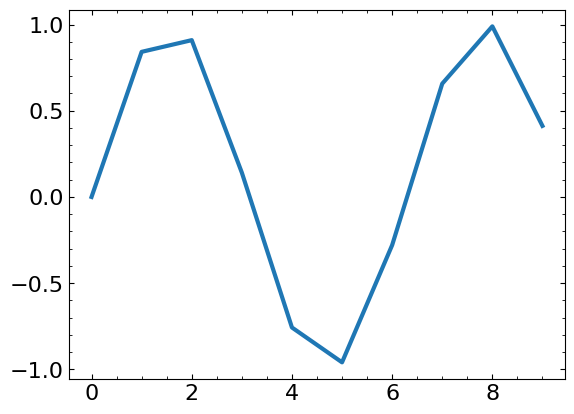

In [81]:
import matplotlib.pyplot as plt

#let's plot a coarse sine function

x = np.arange(10)
y = np.sin(x)
plt.plot(x,y)

Let's fix the problems one by one.

Let's change the font size, line wdith, and axes.


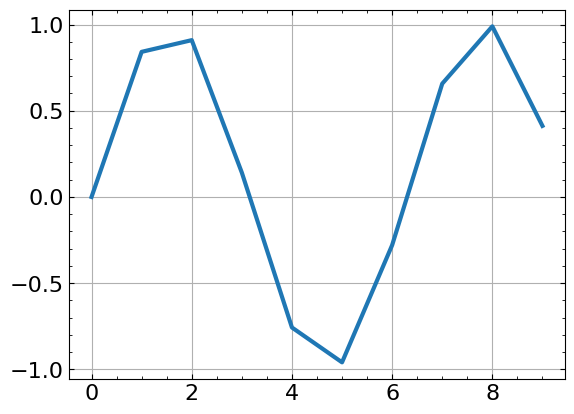

In [82]:
from matplotlib import rc
rc('font', **{'size': 16})
rc('lines', **{'linewidth':3.0})
rc('axes', **{'labelsize':16})

#We can also add tiks inside of the plot.
rc('xtick', **{'direction':'in', 'top':True, 'minor.visible':True})
rc('ytick', **{'direction':'in', 'right':True, 'minor.visible':True})

#and we can turn grid lines on
plt.grid()
plt.plot(x,y)

You can preconfigure matplotlib using a file and the following line:

In [83]:
#plt.style.use('configname.mplstyle')

An example of what the config file could look like is this:

font.size : 16

lines.linewidth : 3.0

savefig.facecolor : white

axes.labelsize : 16

xtick.direction : in

xtick.top : True

xtick.minor.visible : True

ytick.direction : in

ytick.right : True

ytick.minor.visible : True





Onto the next issue, we didn't plot anywhere near enough points to create a smooth curve. To remedy this, we can use np.linspace like before:

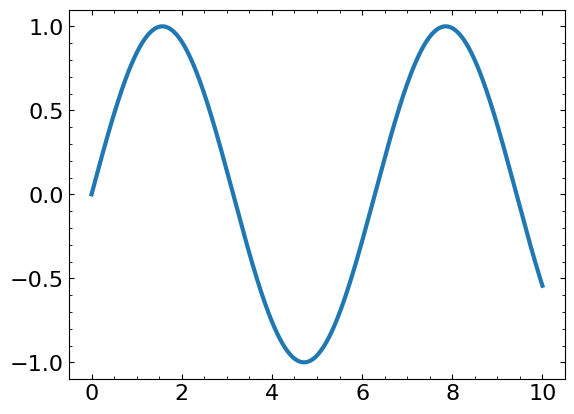

In [84]:
x = np.linspace(0,10,1000)
y=np.sin(x)
plt.plot(x,y)

To label our axes, we can do the following:

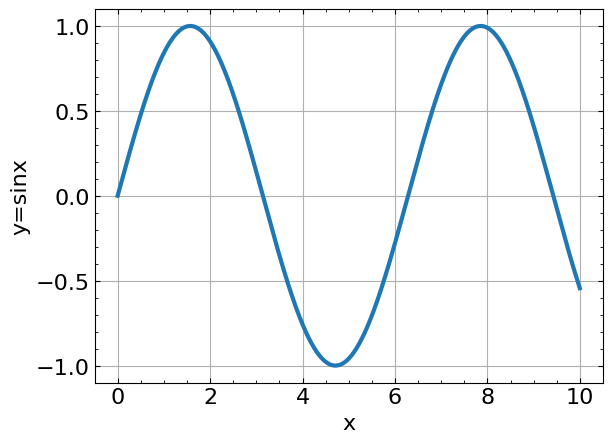

In [85]:
plt.xlabel("x")
plt.ylabel("y=sinx")
plt.tight_layout()

plt.grid()
plt.plot(x,y)

#We can save using the savefig function
#Change the filetype in the directory string

plt.savefig('sine.png')

If we want to plot with points rather than just lines:

Text(0, 0.5, 'y=sin(x)')

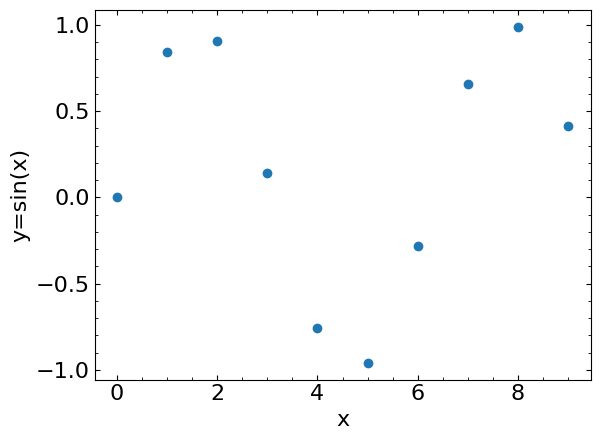

In [86]:
x = np.arange(10)
y = np.sin(x)

#Drawpoints with marker='o'
#Do not draw styles with linestyle = ' '

plt.plot(x,y, marker='o', linestyle='')
plt.xlabel('x')
plt.ylabel('y=sin(x)')

Remember that matplotlib will draw lines in the order that the commands are given, so each curve will be on top of the old curves.
A legend can be called using plt.legend()

Here's an example

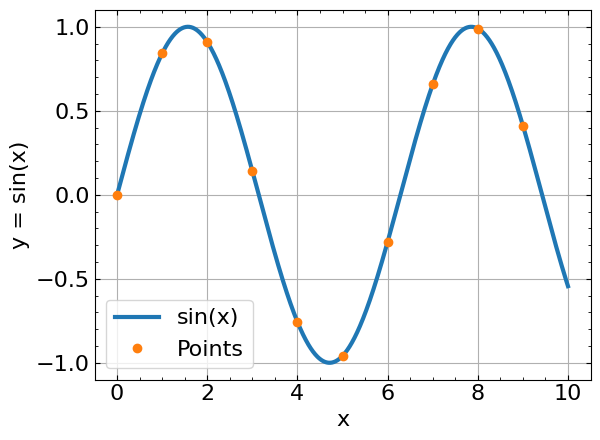

In [87]:
x = np.linspace(0, 10, 1000)
y = np.sin(x)
plt.plot(x, y, label='sin(x)')
x_pts = np.arange(10)
y_pts = np.sin(x_pts)
plt.plot(x_pts, y_pts, label='Points', linestyle='', marker='o')
plt.xlabel('x')
plt.ylabel('y = sin(x)')
plt.grid()
plt.legend()

---

If one wants to plot data as opposed to simple functions, a good standard function to read is np.genfromtxt().
The function needs a filename, and must be accesible by the python file or notebook.

The most important parameters for you to know about are delimiter and skip header. The delimiter
value tells Python how values are separated. For example, if you are reading in a .csv file, you will want to
use delimiter=',' (note the quotes!). A plain text file might have a space as the delimiter, which is what
numpy will assume if you don’t tell it otherwise. The skip header value tells Python how many lines to skip
at the beginning of your file.

You may load in a text or csv file directly into an array as follows:

In [88]:
#mydata = np.genfromtxt('myfile.txt')

To get the first column:

In [89]:
#firstcol = mydata[:,0]

#the colon means to take data from all rows
#the 0 means to take only from the first element.

To get only the first row:

In [90]:
#firstrow = mydata[0]

To save data to a file:

In [91]:
#np.savetxt('filename', mydata)

---

#**Lists vs Arrays**

Look below:

In [92]:
#Here is a list:

x = [0,1,2,3,4]
print(x)

#Here is the same list as an array

x = np.arange(5)
print(x)

#They may look the same, but there are no commas within the array


[0, 1, 2, 3, 4]
[0 1 2 3 4]


These may look similar, however a list as compared to an array is a collection of *any* set of things. An array is of the same type of element.

The drawback of this is that if you want to operate on the list, there is no garuntee that every element can except such an operation.

An array must have its size and type pre-specified. Arrays also live in blocks of memory where each element is stored consecutively, making it faster to operate on compared to a list where free storage must be sought out.

One can also turn an array (in this case an linspace array) into a list assuming the requirements are met.

In [93]:
x = np.linspace(-5 , 5 , 100)
xlist = list(x)

print(xlist)

[np.float64(-5.0), np.float64(-4.898989898989899), np.float64(-4.797979797979798), np.float64(-4.696969696969697), np.float64(-4.595959595959596), np.float64(-4.494949494949495), np.float64(-4.393939393939394), np.float64(-4.292929292929293), np.float64(-4.191919191919192), np.float64(-4.090909090909091), np.float64(-3.9898989898989896), np.float64(-3.888888888888889), np.float64(-3.787878787878788), np.float64(-3.686868686868687), np.float64(-3.5858585858585856), np.float64(-3.484848484848485), np.float64(-3.383838383838384), np.float64(-3.282828282828283), np.float64(-3.1818181818181817), np.float64(-3.080808080808081), np.float64(-2.9797979797979797), np.float64(-2.878787878787879), np.float64(-2.7777777777777777), np.float64(-2.676767676767677), np.float64(-2.5757575757575757), np.float64(-2.474747474747475), np.float64(-2.3737373737373737), np.float64(-2.272727272727273), np.float64(-2.1717171717171717), np.float64(-2.070707070707071), np.float64(-1.9696969696969697), np.float64(-

In [94]:
#Demonstrating the difference in speed between the methods:

%timeit y = np.sin(x)

%timeit y = [np.sin(i) for i in xlist]

2.13 µs ± 51.8 ns per loop (mean ± std. dev. of 7 runs, 100000 loops each)
135 µs ± 32 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)


As can be easily seen, the method with arrays is almost 60x faster. This makes arrays computationally preferable.

---

#**Common Bugs and Error Messages**

**Common Bugs that Do Not Produce an Error Message**

- Improper Order of Operations (e.g. b/2*a vs b/(2*a))
- Defining a variable more than once when not intended.
- Good practice is to make sure to pass variables either as arguments or define them within a function when using or returning them as a function.

**Common Warnings**

- Divide by zero (+/0 will yield inf, -/0 will yield -inf, and 0/0 will give nan)
- Overflow or underflow

**Common Errors**
- NameError -> Uusally means you forgot to import or define some function or package.
- SynthaxError -> Code cannot be run because something like a bracket was lost.
- IndexError -> Tried to call an element of an array that doesn't exist.
- TypeError -> Tried to operate 2 things that don't combine (ex: 5*np.sin)
- ValueError -> The truth value of an array with more than one element is ambiguous. Tends to happen when you combine an if statement with an array.





# **Notes on Latex**

Within a markdown cell, you can write in latex by bordering an expression within two $ signs.

Ex:

$x + 1$

Two $ signs will yield a display equation:

Ex:

$$x+1$$

One can also translate a python line into latex:

In [95]:
#For example:

x=1

z = np.exp(-x) + x*(y**2+3*x)

from sympy import latex, sympify

print(latex(sympify('exp(-x)+x*(y**2+3*x)')))


x \left(3 x + y^{2}\right) + e^{- x}


Writing this down in a markdown cell you get this:

$ x\left(3 x + y^{2}\right) + e^{-x} $


# **That's it for the basic applications of python for the Physical Sciences**
